<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/Prueba_de_Frecuencias_(24022026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#<span style="color:brown;">**Prueba de Frecuencias para números aleatorios**</span>
<span style="color:blue;"></span>



**Interpretación de la Prueba de Frecuencia**

La *Prueba de Frecuencia* (también conocida como prueba monobit) es una prueba estadística utilizada para evaluar la aleatoriedad de una secuencia binaria. Su objetivo principal es verificar si la cantidad de ceros y unos en la secuencia es aproximadamente la misma, como se esperaría en una secuencia verdaderamente aleatoria.

Fundamento


En una secuencia aleatoria de longitud $n$, la probabilidad de obtener un 0 o un 1 es $p = 0.5$. Por lo tanto, se espera que el número de unos sea aproximadamente $\frac{n}{2}$.
Para aplicar la prueba, se realiza la siguiente transformación:

*   Cada bit 0 se convierte en $-1$
*   Cada bit 1 se convierte en $+1$


Luego se calcula la suma total:


$$ S_n = \sum_{i=1}^{n} X_i$$


donde $X_i \in \{-1, +1\}$.

*Estadístico de prueba*

El estadístico normalizado se calcula como:


$$ S = \frac{|S_n|}{\sqrt{n}}$$


Este valor se utiliza para calcular el valor-$p$ mediante la función error complementaria:


$$ p\text{-valor} = \operatorname{erfc}\left( \frac{S}{\sqrt{2}} \right)$$

Interpretación



*   Si el $p$-valor $\geq \alpha$ (nivel de significancia, típicamente $\alpha = 0.01$ o $0.05$), \textbf{no se rechaza} la hipótesis nula. La secuencia pasa la prueba de frecuencia.
*   Si el $p$-valor $< \alpha$, se \textbf{rechaza} la hipótesis nula. La secuencia no presenta un comportamiento compatible con aleatoriedad en términos de balance entre ceros y unos.



In [21]:
import numpy as np # Importa la librería NumPy para operaciones numéricas y manipulación de arrays.
from scipy.stats import norm # Importa la función 'norm' de SciPy para cálculos relacionados con la distribución normal.
import scipy.stats as st # Importa el módulo 'stats' completo de SciPy, que contiene muchas funciones estadísticas.
import pandas as pd # Importa la librería Pandas para manipulación y análisis de datos, especialmente con DataFrames.

In [2]:
numeros = [
    [0.78961, 0.05230, 0.10689, 0.55877, 0.14151],
    [0.76086, 0.12079, 0.27738, 0.65726, 0.79269],
    [0.80548, 0.82654, 0.29453, 0.20852, 0.42989],
    [0.58518, 0.98611, 0.34488, 0.34358, 0.11537],
    [0.89898, 0.57880, 0.67621, 0.05010, 0.00121],
    [0.28269, 0.73059, 0.70119, 0.18284, 0.49962],
    [0.38618, 0.76910, 0.68834, 0.55170, 0.10850],
    [0.79982, 0.45679, 0.21631, 0.87616, 0.55743],
    [0.58962, 0.33216, 0.03185, 0.61168, 0.09264],
    [0.69823, 0.17028, 0.05475, 0.91512, 0.76262],
    [0.29931, 0.30861, 0.83358, 0.51781, 0.03272],
    [0.57410, 0.26593, 0.85903, 0.48338, 0.35288],
    [0.24000, 0.65559, 0.38507, 0.90829, 0.94187],
    [0.93655, 0.88809, 0.81772, 0.36982, 0.19904],
    [0.54325, 0.62400, 0.09133, 0.41678, 0.33954],
    [0.58244, 0.85853, 0.88752, 0.38729, 0.15506],
    [0.23949, 0.53559, 0.33881, 0.49883, 0.75103],
    [0.19962, 0.65002, 0.74579, 0.79113, 0.63453],
    [0.19147, 0.40644, 0.08128, 0.73435, 0.22724],
    [0.22287, 0.07281, 0.64183, 0.44267, 0.72102]
]

Aplicamos la prueba de estadisticos

In [3]:
# Aplanar la lista de listas en una sola lista
datos_de_numeros = [item for sublista in numeros for item in sublista]

Se clasificaran nuestros datos de la siguiente  manera

In [23]:
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.01] # Intervalos

# Clasificar datos en intervalos
indices = np.digitize(datos_de_numeros, bins, right=False)

# Contar cuántos hay en cada intervalo
conteos = [(indices == i).sum() for i in range(1, len(bins))]



In [22]:
print(conteos)

[np.int64(21), np.int64(22), np.int64(19), np.int64(23), np.int64(15)]

In [6]:

# Total de datos
n = len(datos_de_numeros)
k = len(bins) - 1


In [7]:

# Frecuencia esperada
FE = n / k

# Frecuencia observada
frecuencia = np.array(conteos)

# Frecuencia acumulada
frecuencia_acum = np.cumsum(frecuencia)

# Frecuencia relativa
frecuencia_rel = frecuencia / n

# Frecuencia relativa acumulada
frecuencia_rel_acum = np.cumsum(frecuencia_rel)

# Marcas de clase
marcas_clase = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]

# Cálculos chi-cuadrada
fi_menos_FE = frecuencia - FE
cuadrado = fi_menos_FE**2
chi_individual = cuadrado / FE

chi_total = chi_individual.sum()



In [24]:

# Crear tabla
tabla = pd.DataFrame({
    "Intervalo": [f"[{bins[i]} - {bins[i+1]})" for i in range(len(bins)-1)],
    "Marca de clase (xi)": marcas_clase,
    "Frecuencia (fi)": frecuencia,
    "Frecuencia acumulada (Fi)": frecuencia_acum,
    "Frecuencia relativa (hi)": frecuencia_rel,
    "Frecuencia relativa acumulada (Hi)": frecuencia_rel_acum,
    "FE": FE,
    "fi - FE": fi_menos_FE,
    "(fi - FE)^2": cuadrado,
    "(fi - FE)^2 / FE": chi_individual
})

# Seleccionar y renombrar las columnas para la tabulación solicitada
tabla_final = tabla[["Intervalo", "Frecuencia (fi)", "FE", "(fi - FE)^2 / FE"]].copy()
tabla_final.columns = ["Intervalo", "Frecuencia Observada", "Frecuencia Esperada", "X^2 "]



In [25]:
print(tabla_final)
print("\nEstadístico Chi-cuadrada total:", chi_total)

      Intervalo  Frecuencia Observada  Frecuencia Esperada  X^2 
0     [0 - 0.2)                    21                 20.0  0.05
1   [0.2 - 0.4)                    22                 20.0  0.20
2   [0.4 - 0.6)                    19                 20.0  0.05
3   [0.6 - 0.8)                    23                 20.0  0.45
4  [0.8 - 1.01)                    15                 20.0  1.25

Estadístico Chi-cuadrada total: 2.0


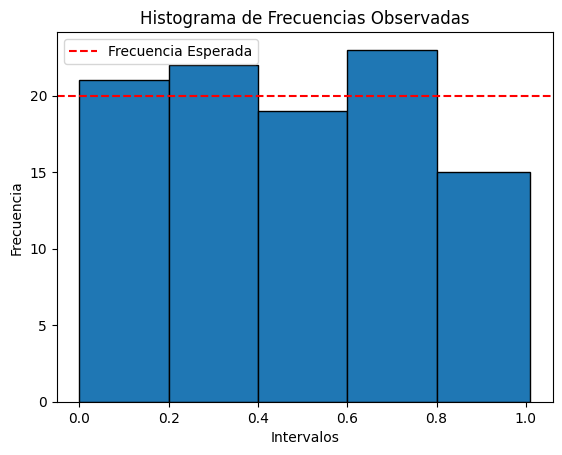

In [28]:
import matplotlib.pyplot as plt

# Histograma de frecuencias observadas
plt.hist(datos_de_numeros, bins=bins, edgecolor='black')
plt.title("Histograma de Frecuencias Observadas")
plt.xlabel("Intervalos")
plt.ylabel("Frecuencia")
plt.axhline(y=20, color='red', linestyle='--', label='Frecuencia Esperada')
plt.legend()
plt.show()

La gráfica muestra un histograma de las frecuencias observadas de los datos agrupados en distintos intervalos. Cada barra representa la cantidad de valores que pertenecen a un intervalo específico.

La línea horizontal discontinua indica la frecuencia esperada bajo el supuesto de una distribución uniforme. Si las alturas de las barras son aproximadamente iguales y cercanas a dicha línea, los datos presentan un comportamiento compatible con uniformidad. En cambio, desviaciones notables respecto a la línea sugieren que los datos podrían no seguir una distribución uniforme.

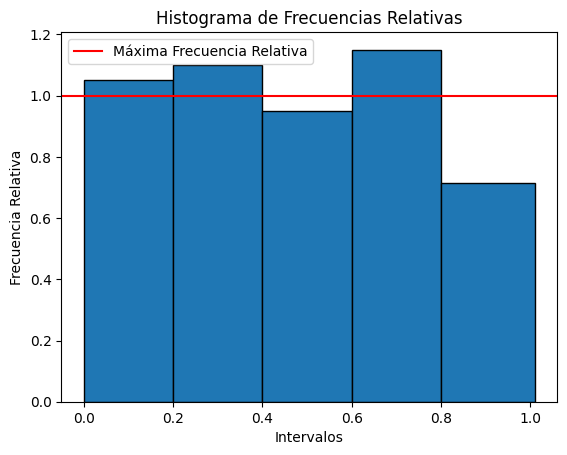

In [19]:
import matplotlib.pyplot as plt

# Histograma de frecuencias relativas
plt.hist(datos_de_numeros, bins=bins, density=True, edgecolor='black')
plt.title("Histograma de Frecuencias Relativas")
plt.xlabel("Intervalos")
plt.ylabel("Frecuencia Relativa")
plt.axhline(y=1, color='red', linestyle='-', label='Máxima Frecuencia Relativa')
plt.legend()
plt.show()

La gráfica muestra un histograma de las frecuencias relativas de los datos agrupados en distintos intervalos. Al utilizar el parámetro *density=True*, las barras representan proporciones normalizadas, de modo que el área total bajo el histograma es igual a 1.

Cada barra indica la frecuencia relativa de los valores dentro de un intervalo específico. La línea horizontal roja representa un valor de referencia para la frecuencia relativa. Si las alturas de las barras son similares entre sí, los datos presentan un comportamiento cercano al esperado bajo una distribución uniforme. En cambio, variaciones notables en las alturas sugieren posibles desviaciones respecto a la uniformidad.



**Criterio de Decisión**

La decisión estadística se toma mediante la comparación entre el estadístico calculado y el valor crítico:




*   Si $\chi^2_{\text{total}} < \chi^2_{\text{critical}}$, no se rechaza la hipótesis nula $H_0$. Esto indica que no existe evidencia estadísticamente significativa para afirmar que los datos se desvían de una distribución uniforme. En consecuencia, los números generados pasan la prueba de uniformidad al nivel de significancia considerado.


*   Si $\chi^2_{\text{total}} \geq \chi^2_{\text{critical}}$, se rechaza la hipótesis nula $H_0$. Esto implica que existe evidencia estadísticamente significativa para concluir que los datos no siguen una distribución uniforme. En consecuencia, los números generados no superan la prueba de uniformidad.






In [20]:
from scipy.stats import chi2

# Grados de libertad (k - 1)
df = k - 1

# Nivel de significancia (alpha)
alpha = 0.05

# Valor crítico de Chi-cuadrada
chi_critical = chi2.ppf(1 - alpha, df)

# Comparar el estadístico chi_total con el valor crítico
if chi_total < chi_critical:
    resultado_prueba = "La prueba de frecuencia PASA (no se rechaza la hipótesis nula)"
else:
    resultado_prueba = "La prueba de frecuencia NO PASA (se rechaza la hipótesis nula)"

print(f"Grados de libertad (df): {df}")
print(f"Nivel de significancia (alpha): {alpha}")
print(f"Valor crítico de Chi-cuadrada: {chi_critical:.4f}")
print(f"Estadístico Chi-cuadrada total: {chi_total:.4f}")
print(f"\nResultado de la prueba: {resultado_prueba}")

Grados de libertad (df): 4
Nivel de significancia (alpha): 0.05
Valor crítico de Chi-cuadrada: 9.4877
Estadístico Chi-cuadrada total: 2.0000

Resultado de la prueba: La prueba de frecuencia PASA (no se rechaza la hipótesis nula)


**Consideraciones Finales**

Es importante destacar que la decisión se basa en un nivel de significancia $\alpha$, el cual representa la probabilidad de rechazar incorrectamente una hipótesis nula verdadera (error tipo I). Por tanto, no rechazar $H_0$ no garantiza que la distribución sea perfectamente uniforme, sino únicamente que no se dispone de evidencia suficiente para afirmar lo contrario con el nivel de confianza establecido.

**Conclusión**

La Prueba de Frecuencia únicamente evalúa el equilibrio global entre ceros y unos. Una secuencia puede pasar esta prueba y aun así no ser completamente aleatoria, por lo que normalmente se utiliza junto con otras pruebas estadísticas dentro de baterías como las propuestas por el *NIST*.